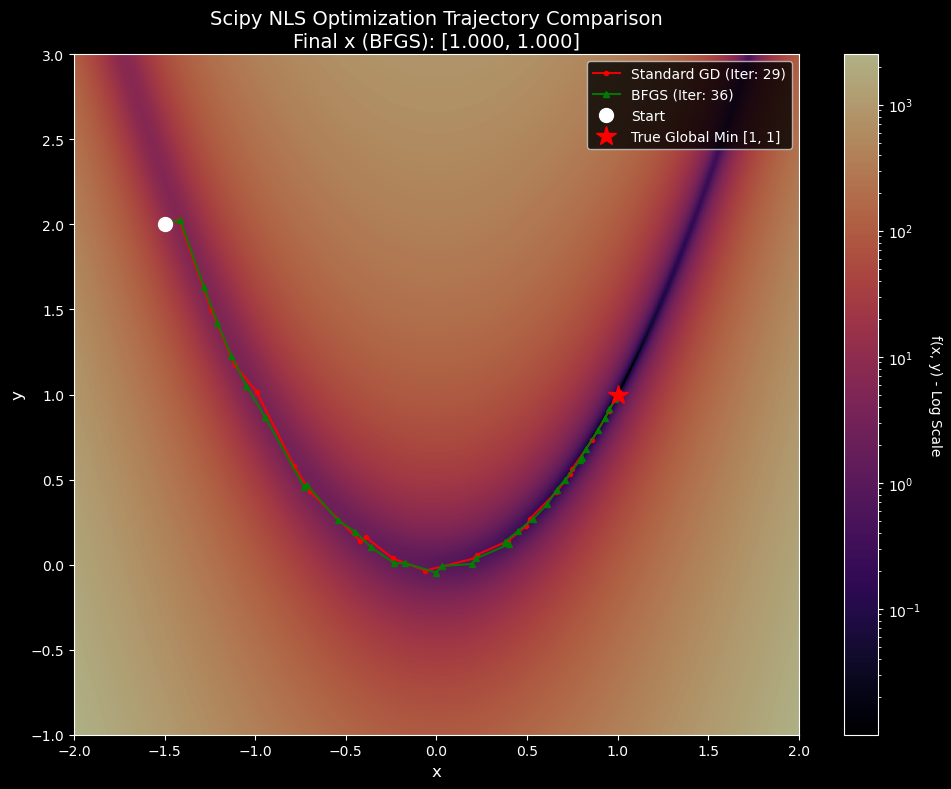

Optimizer    | Iterations | Final Loss | Termination
-----------------------------------------------------------------
GD (CG)      | 29         | 2.03e-11   | True
BFGS         | 36         | 9.18e-12   | False


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib.colors as colors

# --- Callback function to record optimization history ---
def make_callback(path):
    def callback(xk):
        path.append(np.copy(xk))
    return callback

# 1. Define the objective function (Rosenbrock)
def rosenbrock(x):
    """
    Rosenbrock "valley" function: classic optimization benchmark.
    Optimal solution is [1, 1] with f(x) = 0.
    """
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2. Setup the Optimization
# Starting point, well away from the minimum
x0 = np.array([-1.5, 2.0])

# Lists to store the full path and values for plotting
path_gd = [np.copy(x0)]
values_gd = [rosenbrock(x0)]

path_bfgs = [np.copy(x0)]
values_bfgs = [rosenbrock(x0)]

# Run Standard Gradient Descent (via minimize with strict tolerances)
# We will use 'CG' (Conjugate Gradient) which behaves similarly to steep descent
# on this simple quadratic-like problem.
res_gd = minimize(
    rosenbrock, 
    x0, 
    method='CG', 
    callback=make_callback(path_gd), 
    tol=1e-5
)

# Run BFGS (Quasi-Newton method)
res_bfgs = minimize(
    rosenbrock, 
    x0, 
    method='BFGS', 
    callback=make_callback(path_bfgs), 
    tol=1e-5
)

# Convert paths to numpy arrays for slicing
path_gd = np.array(path_gd)
path_bfgs = np.array(path_bfgs)

# 3. Create the Visualization (Dark Background)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

# Define grid for the heatmap
x_range = np.linspace(-2, 2, 500)
y_range = np.linspace(-1, 3, 500)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

# Plot the heatmap (using log scale for better contrast in a valley)
im = ax.imshow(
    Z, 
    extent=[-2, 2, -1, 3], 
    origin='lower', 
    norm=colors.LogNorm(vmin=Z.min()+0.01, vmax=Z.max()),
    cmap='magma', 
    aspect='auto',
    alpha=0.7 # Add slight transparency for better trail visibility
)

# Colorbar for the heatmap
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('f(x, y) - Log Scale', rotation=270, labelpad=15)

# Plot the two optimization trajectories
# Standard GD in red (more likely to follow the curve slowly)
ax.plot(
    path_gd[:, 0], path_gd[:, 1], 
    'r-o', markersize=3, linewidth=1.5, 
    label=f'Standard GD (Iter: {len(path_gd)-1})', alpha=0.9
)

# BFGS in green (more efficient, direct steps)
ax.plot(
    path_bfgs[:, 0], path_bfgs[:, 1], 
    'g-^', markersize=4, linewidth=1.5, 
    label=f'BFGS (Iter: {len(path_bfgs)-1})', alpha=0.9
)

# Start and final points
ax.plot(x0[0], x0[1], 'wo', markersize=10, label='Start')
ax.plot(1, 1, 'r*', markersize=15, label='True Global Min [1, 1]')

# Dynamic title with final result
ax.set_title(
    f'Scipy NLS Optimization Trajectory Comparison\n'
    f'Final x (BFGS): [{res_bfgs.x[0]:.3f}, {res_bfgs.x[1]:.3f}]', 
    fontsize=14
)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 4. Convergence Speed Table
print(f"{'Optimizer':<12} | {'Iterations':<10} | {'Final Loss':<10} | {'Termination'}")
print("-" * 65)
print(f"{'GD (CG)':<12} | {res_gd.nit:<10} | {res_gd.fun:<10.2e} | {res_gd.success}")
print(f"{'BFGS':<12} | {res_bfgs.nit:<10} | {res_bfgs.fun:<10.2e} | {res_bfgs.success}")